In [1]:
import pandas as pd
import numpy as np

In [2]:
sta_conc_naq_df = pd.read_csv(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML 站点 NAQ CT数据\station_conc_naq_hour.csv')
sta_conc_ct_df  = pd.read_csv(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML 站点 NAQ CT数据\station_conc_ct_3hour.csv')

In [3]:
# 确保时间列的格式正确，这里假设时间列名称为 'Station'，需要转换为 datetime 格式
sta_conc_naq_df['Station'] = pd.to_datetime(sta_conc_naq_df['Station'], format='%Y%m%d%H')
sta_conc_ct_df['Station'] = pd.to_datetime(sta_conc_ct_df['Station'], format='%Y%m%d%H')

# 按月份进行分割并存储到字典中
sta_conc_naq_monthly_data = {str(month): data for month, data in sta_conc_naq_df.groupby(sta_conc_naq_df['Station'].dt.to_period('M'))}
sta_conc_ct_monthly_data = {str(month): data for month, data in sta_conc_ct_df.groupby(sta_conc_ct_df['Station'].dt.to_period('M'))}

In [4]:
ym_time = ['2018-01','2018-02','2018-03','2018-04','2018-05','2018-06','2018-07','2018-08','2018-09','2018-10','2018-11','2018-12']
yr_naq = ['naq_01','naq_02','naq_03','naq_04','naq_05','naq_06','naq_07','naq_08','naq_09','naq_10','naq_11','naq_12',]
yr_ct  = ['ct_01','ct_02','ct_03','ct_04','ct_05','ct_06','ct_07','ct_08','ct_09','ct_10','ct_11','ct_12',]
naq_data_dict = {}
ct_data_dict = {}
for ii in range(len(ym_time)):
    naq_data_dict[yr_naq[ii]] = np.mean(sta_conc_naq_monthly_data[ym_time[ii]],axis=0)/1000
    ct_data_dict[yr_ct[ii]]   = np.mean(sta_conc_ct_monthly_data[ym_time[ii]],axis=0)

naq_all_df = pd.DataFrame.from_dict(naq_data_dict, orient='index')
naq_all_df .columns = naq_all_df .columns.str.strip()
ct_all_df = pd.DataFrame.from_dict(ct_data_dict, orient='index')
ct_all_df.columns = ct_all_df.columns.str.strip()

c:\Users\zouzhiyin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3462: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [5]:
obs_names = ['ALT','ASC','ASK','AZR','BHD','BKT','BMW','BRW','CBA','CGO',\
             'CHR','CRZ','EIC','GMI','HUN','ICE','IZO','KEY','KUM','LEF',\
             'MHD','MID','MLO','NMB','NWR','PAL','PSA','RPB','SEY','SGP',\
             'SHM','SMO','SPO','SUM','SYO','TAP','USH','UTA','UUM','WIS',\
             'WLG','ZEP' ]

In [6]:
ct_names_layer1 = ['AZR','BHD','BMW','BRW','CBA','CGO','CHR','EIC','GMI','HUN',\
                   'ICE','KEY','KUM','MHD','MID','NMB','PSA','RPB','SEY','SGP',\
                   'SHM','SMO','SYO','TAP','USH','UTA','UUM','WIS']

In [7]:
naq_names_layer1 =  ['ALT','ASC','AZR','BHD','BMW','BRW','CBA','CGO','CHR','EIC',\
                     'GMI','HUN','ICE','KEY','KUM','LEF','MHD','MID','NMB','PSA',\
                     'RPB','SEY','SGP','SHM','SMO','SYO','TAP','USH','UTA','UUM',\
                     'WIS' ]

diff  = ['ALT','ASC','LEF']

In [8]:
gml_out_obspack = ['KUM', 'NMB',  'TAP', 'USH', 'UTA', 'UUM', 'WIS']
gml_in_obspack = ['ASK', 'AZR',  'BMW', 'CBA', 'KEY', 'SHM','SMO','SPO','SUM']
#obs_names_layer1 =  ['ALT','ASC','AZR','BHD','BMW','BRW','CBA','CGO','CHR','EIC',\
#                     'GMI','HUN','ICE','KEY','KUM','LEF','MHD','MID','NMB','PSA',\
#                     'RPB','SEY','SGP','SHM','SMO','SYO','TAP','USH','UTA','UUM',\
#                     'WIS' ]
obs_names=  ['ASK', 'AZR',  'BMW', 'CBA', 'KEY', 'KUM','NMB', 'SHM','SMO','SPO','SUM','TAP','USH','UTA','UUM','WIS']

In [9]:
def get_obs(obs_name):
    df = pd.read_csv(f'D:/workdata/25/global_monmean_obs_co2/txt.{obs_name}',header=None,sep=' ')
    data = df.values
    data = data[-12:,2]
    return data

In [10]:
obs_data = np.zeros((12,16))
for ii in range(16):
    obs_name = obs_names[ii]
    #print(obs_name)    
    #print(get_obs(obs_name))
    obs_data[:,ii] = get_obs(obs_name)


In [11]:
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter

In [12]:
#横轴
#xx3h = np.arange(6*24,99*24,3)+1  #ct
xxh = np.arange(8761)+1 #naq,obs
xxm = np.arange(12)+1

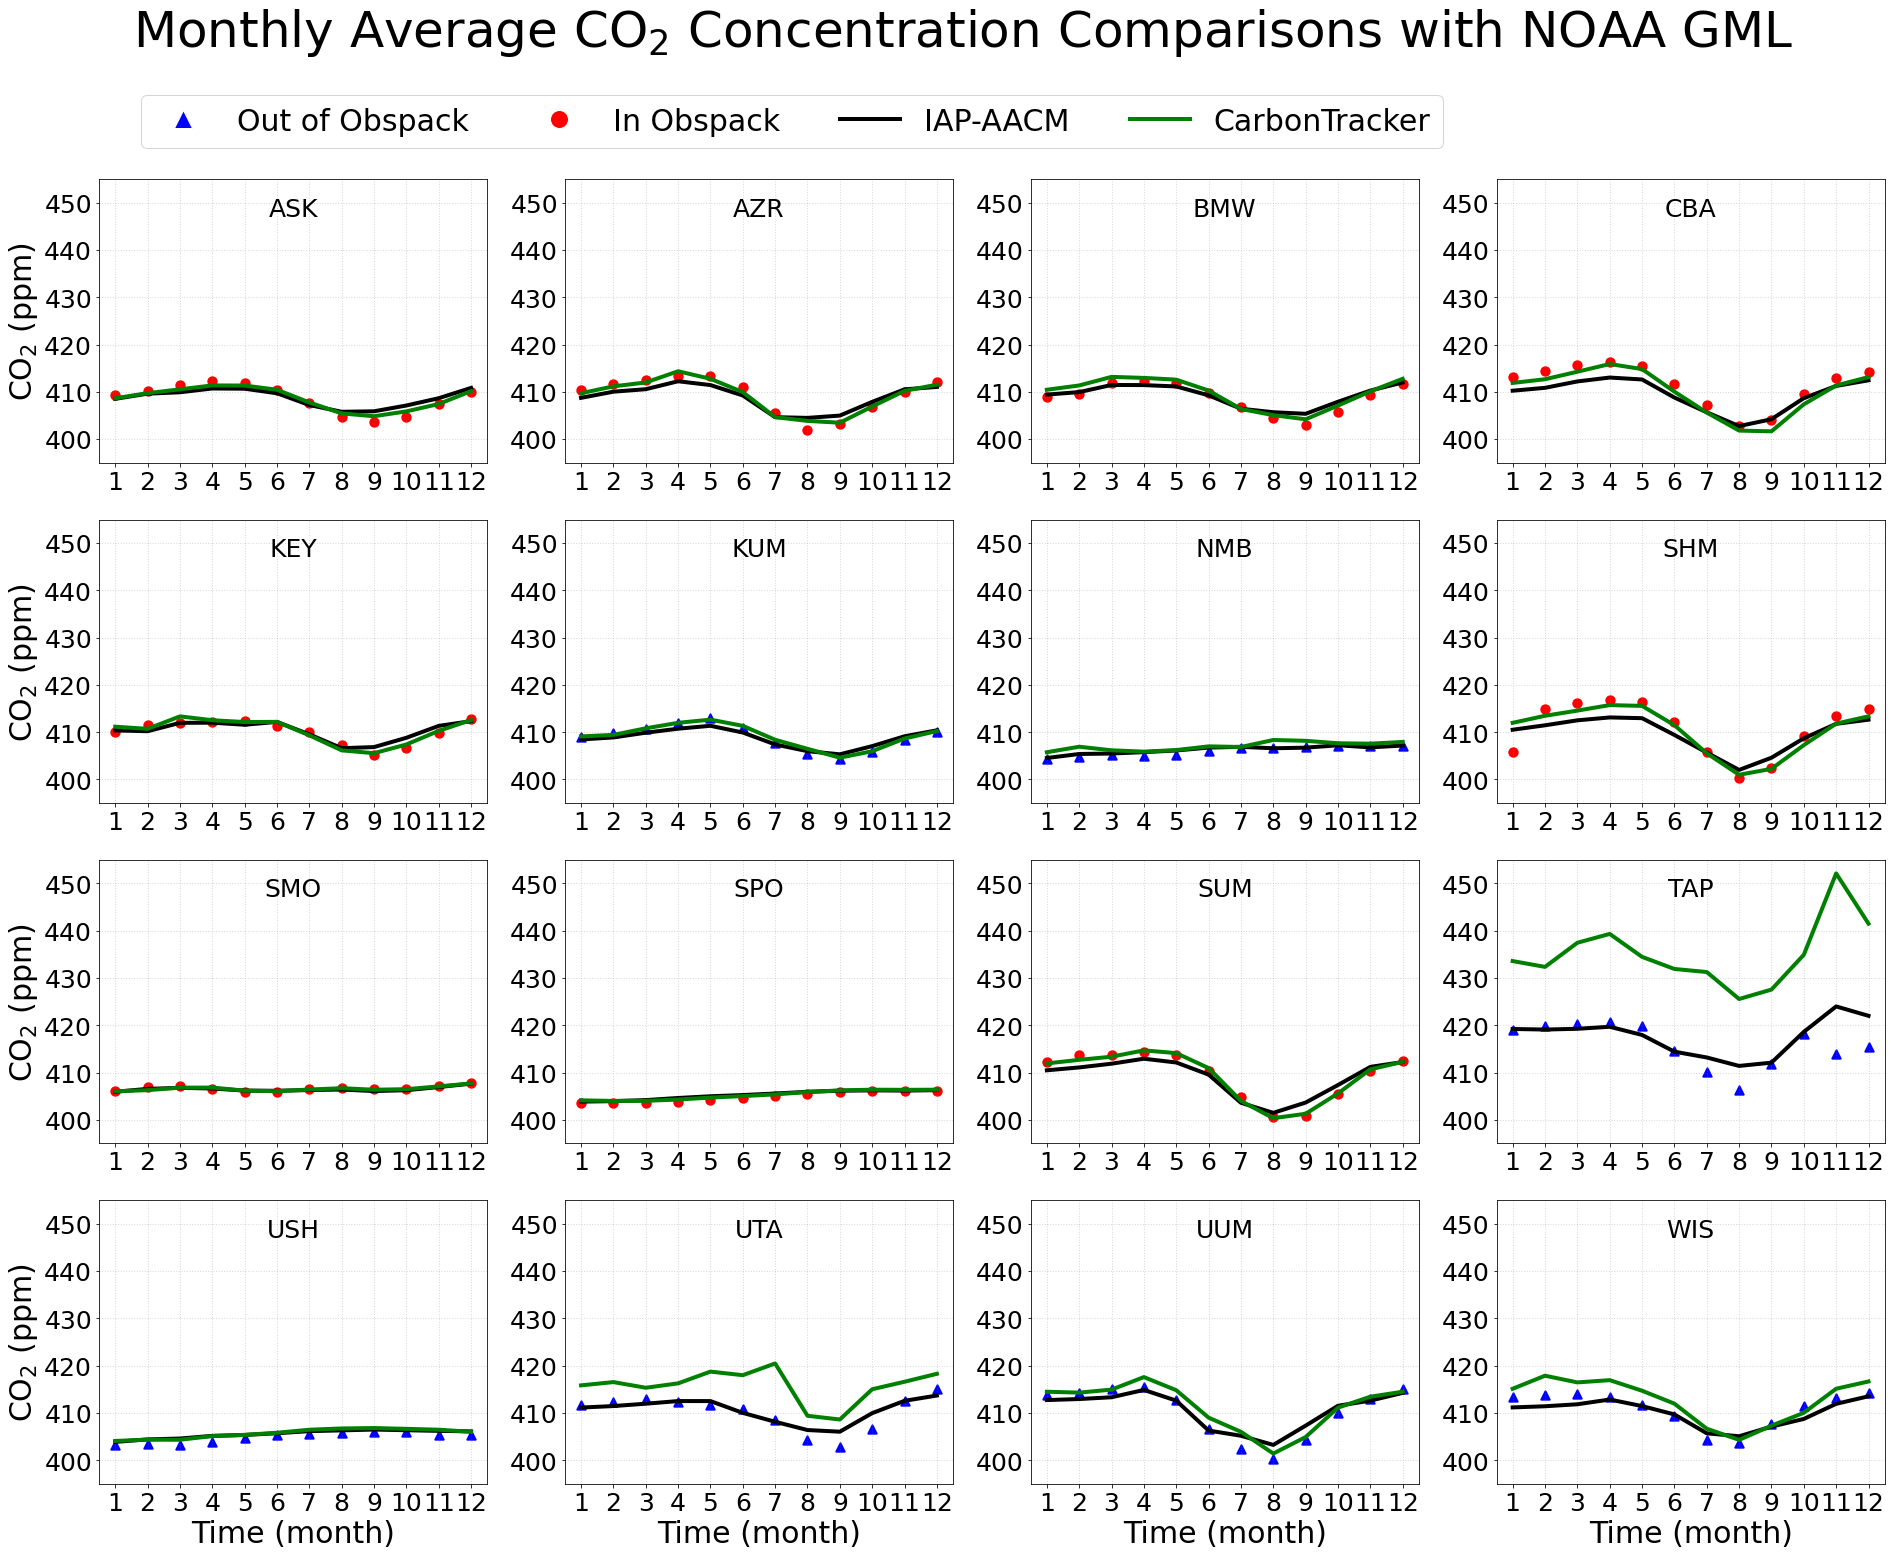

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker

fig, ax = plt.subplots(4, 4, figsize=(32,24))

#variables = ('J','F','M','A','M','J','J','A','S','O','N','D')
variables = ('1','2','3','4','5','6','7','8','9','10','11','12')
xv = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# 确保数据数组的列数足够（至少为30列），否则会出错
num_plots = 4 * 4  # 6行5列 = 30个子图
#data_columns = min(obs_data.shape[1], naq_data.shape[1], wrfc_data.shape[1], ct_data.shape[1])

for i, row in enumerate(ax):
    for j, col in enumerate(row):
        idx = i * 4 + j  # 计算索引，确保不超过实际数据列数
        #if idx >= 27:
            #continue  # 如果索引超出了数据的列数，则跳过

        plt.ylim([390, 425])  # 设置y轴的范围
        col.set(xlim=(0.5, 12.5), ylim=(395, 455))
        col.yaxis.set_major_locator(ticker.MultipleLocator(10))
        col.tick_params(axis='y', labelsize=20) 
        col.set_xticks(xv)
        col.set_xticklabels(variables, fontsize=20)
        col.grid(which='both', ls=':', lw=1, color='grey', alpha=0.3)
        col.tick_params(axis='x', labelsize=25)  # x轴刻度字体大小
        col.tick_params(axis='y', labelsize=25)  # y轴刻度字体大小

        if obs_names[idx] in gml_out_obspack:
            col.set_title(obs_names[idx], y=0.85, fontsize=25)
            col.scatter(xxm, obs_data[:, idx], marker='^', s=70,color="blue", linewidth=2.0,)
            col.plot(xxm, naq_all_df[obs_names[idx]], ls='-', color="black", linewidth=4, label='IAP-AACM')
            #col.plot(xxm, wrfc_data[:, idx], ls='-', color="red", linewidth=1.5, label='WRF-Chem')
            col.plot(xxm, ct_all_df[obs_names[idx]], ls='-', color="green", linewidth=4, label='CarbonTracker')
        elif obs_names[idx] in gml_in_obspack:
            col.set_title(obs_names[idx], y=0.85, fontsize=25)

            # 绘制数据
            col.scatter(xxm, obs_data[:, idx], marker='o',s=70, color="red", linewidth=2.0,)
            col.plot(xxm, naq_all_df[obs_names[idx]], ls='-', color="black", linewidth=4, label='IAP-AACM')
            #col.plot(xxm, wrfc_data[:, idx], ls='-', color="red", linewidth=1.5, label='WRF-Chem')
            col.plot(xxm, ct_all_df[obs_names[idx]], ls='-', color="green", linewidth=4, label='CarbonTracker')
        #else :
        #    col.set_title(obs_names[idx], y=0.85, fontsize=20)
        #    # 绘制数据
        #    col.scatter(xxm, obs_data[:, idx], marker='o',s=60, color="red", linewidth=1.5,)
        #    col.plot(xxm, naq_all_df[obs_names[idx]], ls='-', color="black", linewidth=3, label='NAQPMS')
        #    #col.plot(xxm, wrfc_data[:, idx], ls='-', color="red", linewidth=1.5, label='WRF-Chem')
        #    col.plot(xxm, ct_all_df[obs_names[idx]], ls='-', color="green", linewidth=3, label='CarbonTracker')

        if j == 0:
            col.set_ylabel('CO$_{2}$ (ppm)', fontsize=30)
        if i == 3:  # 注意这里应该是 5 而不是 6，因为索引是从 0 开始的
            col.set_xlabel('Time (month)', fontsize=30)

# 图例
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Out of GLOBALVIEW', markerfacecolor='blue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='In GLOBALVIEW', markerfacecolor='red', markersize=12),
    Line2D([0], [0], color='black', lw=4, label='IAP-AACM'),
    Line2D([0], [0], color='green', lw=4, label='CT2022')
    # 你可以在这里加 WRFChem 曲线图例
]

# 添加图例（位置你可以根据需要调整）
ax[0][0].legend(handles=legend_elements, prop={'size': 30}, frameon=True,
                bbox_to_anchor=(3.5, 1.35), ncol=4, markerscale=1.5)

# 设置标题
plt.suptitle('Comparison of Monthly Mean CO$_{2}$ Concentration', fontsize=50, y=0.98)

# 图像分辨率
plt.rcParams['savefig.dpi'] = 500

plt.savefig(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\论文用图v5\站点月均折线图IAPAACMCT.r5.png',bbox_inches='tight')#----------
#plt.savefig(r'D:\论文撰写\加拿大野火模拟\数据作图\站点月均折线图naq71.png',bbox_inches='tight')#----------
